# Testing Reg_m and Reg, Deviance Selection
Now that we have an optimized deviance-guided approach to perform UOT, it is important to fine-tune reg_m and reg to get the best clustering results possible. For this purpose, we'll perform UOT for multiple reg_m values, select the one giving the best clustering performance, and then test multiple reg values for this reg_m value.

## Imports

In [2]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [3]:
### Directories and Files ###
root = '../../../../../'
metadata_dir = f"{root}Data/sc_data/cell_types.tsv"
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data' # Importing was not working with relative root+'..' approach, so replace with local data
save_dir = f"{root}Generated Data/Single-to-single/sc_uot_clustering/OT/DevianceSelection/ParameterTesting"
outlier_dir = f"{root}Generated Data/Single-to-single/outliers/outliers_immune_iqr15.csv"

In [4]:
### Imports ###
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from umap import UMAP
from time import perf_counter
sys.path.append(root+'Scripts')
from hicdatautils import hic_ot_optim, subset_clr_data

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
### Pre-importing metadata ###
metadata_df = pd.read_csv(metadata_dir, sep="\t")
metadata_df

,cell_name,cell_type
0,arc_pair_7,T cells
1,arc_pair_18,CD4+ T cells
2,arc_pair_31,CD4+ T cells
3,arc_pair_56,T cells
4,arc_pair_57,CD8+ T cells
...,...,...
8058,arc_pair_736107,T cells
8059,arc_pair_736132,CD8+ T cells
8060,arc_pair_736144,CD8+ T cells
8061,arc_pair_736230,Monocytes


In [6]:
### Importing outliers ###
outliers = pd.read_csv(outlier_dir, usecols=["cell_name"])
outliers_list = list(outliers["cell_name"].values)

## Helper Functions

### Data Handling

In [7]:
def generate_ot_data(
        reg_m: float, 
        top_number : int = 500,
        count: int=25, 
        seed: int=42,
        reg: float|None=None
        ) -> tuple[pd.DataFrame, float]:
    '''
        Generates pair-wise OT comparison data for the immune cell data
        using the provided arguments. Additionally, keeps track of computation
        time.

        Function is specific to this notebook.

        Parameters
        ----------
        reg_m : float
            Unbalanced parameter to use.
        top_number : int
            Top number of contacts to use based on deviance.
            Default = 250.
        cell_count : int
            The top number of cells to be used.
            Default = 20.
        seed : int
            Seed for subsetting.
            Default = 42.
        reg : float | None
            Regularization parameter for Sinkhorn regularization.
            Default = None, uses no regularization.

        Returns
        -------
        ot_results : pd.DataFrame
            Pandas dataframe with the desired results.
    '''
    # Subsetting
    clrs = subset_clr_data(data_dir, metadata_df, count, seed, exclude=outliers_list)
    
    # OT
        # Starting timer
    start_time = perf_counter()

        # Calculations
    ot_results = hic_ot_optim(
        clrs,
        "chr1",
        "deviance",
        "max",
        reg_m,
        reg,
        top_contacts=top_number,
        n_jobs=8
    )
    
        # Stopping timer
    end_time = perf_counter() - start_time

        # Saving results
    ot_results.to_csv(f'{save_dir}/IMMUNE_CELLS_DEVIANCE_unbalanced_reg_m={reg_m}_cluster_top={top_number}_count={count}_seed={seed}_reg={reg}.csv')

    return ot_results, end_time

def load_ot_data_numpy(
        reg_m: float,
        top_number: int=500,
        count: int=25,
        seed: int=42,
        reg: float|None=None,
        condense: str="full"
        ) -> tuple[np.ndarray, list[str]]:
    
    '''
        Loads OT results for immune cell data as an ndarray
        of OT results and a list of cell types.

        This function is very specific to this notebook.

        Parameters
        ----------
        reg_m : float
            Unbalanced parameter used.
        top_number : int
            Top number of contacts used.
        count : int
            Number of cells per cell type used for analysis.
            Default = 20.
        seed : int
            Seed used to select data.
            Default = 42.
        reg : float | None
            Regularization parameter for Sinkhorn regularization.
            Default = None, uses no regularization.
        condense : str
            Controls the extent to which the cell types are condensed.
            Options include "full", "half" and "not".
            Default = "full.

        Returns
        -------
        ot_ndarray : np.ndarray
            OT results in ndarray form.
        cell_types : list[str]
            List of cell types in the same order as original
            data.
    '''
    # File
    file = f"{save_dir}/IMMUNE_CELLS_DEVIANCE_unbalanced_reg_m={reg_m}_cluster_top={top_number}_count={count}_seed={seed}_reg={reg}.csv"


    # Importing file
    ot_df_matrix = pd.read_csv(file, index_col=0)

    # Converting to ndarray
    ot_ndarray = ot_df_matrix.to_numpy()

    # Fetching cell types   
    cell_types = []
    for cell in ot_df_matrix.index:
        specific_type = metadata_df[metadata_df['cell_name'] == cell]['cell_type'].values[0]
        
        if condense == "full":
            lymphoids = ['B cells', 'CD8+ T cells', 'CD4+ T cells', 'T cells', 'NK cells']
            myeloids = ['Dendritic cells', 'Monocytes', 'Neutrophils']

            if specific_type in lymphoids:
                cell_types.append("Lymphoid")
            elif specific_type in myeloids:
                cell_types.append("Myeloid")
            else:
                cell_types.append("Progenitors")
            
        elif condense == "half":
            t_cells = ['CD8+ T cells', 'CD4+ T cells', 'T cells']
            myeloids = ['Dendritic cells', 'Monocytes', 'Neutrophils']

            if specific_type in t_cells:
                cell_types.append("T cells")
            elif specific_type in myeloids:
                cell_types.append("Myeloid cells")
            else:
                cell_types.append(specific_type)

        elif condense == "not":
            cell_types.append(specific_type)
        else:
            raise ValueError(f"Condensation type not recognized: {condense}")

    return ot_ndarray, cell_types

### Visualizing

In [8]:
def generate_clustering(
        data : np.ndarray,
        cell_lines : list[str],
        title : str,
        ax
        ):
    '''
        Draws clustering of the data to the provided Axes object
        using UMAP.

        Parameters
        ----------
        data : np.ndarray
            OT data in ndarray form.
        cell_lines : list[str]
            List of cell lines corresponding to the cell order in
            the data.
        title : str
            Title for the panel
        ax
            Axes object to parse figure to
    '''
    vec = UMAP(n_components=2).fit_transform(data)
    xlab = "UMAP 1"
    ylab= "UMAP 2"

    # Figure
    sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_lines, ax=ax, s=20, linewidth=0)
    handles, labels = ax.get_legend_handles_labels()
    labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
    ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=1)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    return

## Reg_m

### Generating Data

In [9]:
### Setting Parameters ###
reg_m_list = [1e-3, 1e-2, 1e-1, 1, 10, 100]

In [9]:
### Generating Data ###
times_list = []
for reg_m in reg_m_list:
    print(f"Starting OT for reg_m={reg_m}")
    _, time = generate_ot_data(reg_m)
    times_list.append(time)

Starting OT for reg_m=0.001


/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/HiCOT Experimenting/Single Cell/UOT/Immune Cells/../../../../../Scripts/hicdatautils/hicgeneral.py:136: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
100%|██████████| 10731/10731 [00:35<00:00, 305.53it/s]


Starting OT for reg_m=0.01


/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/HiCOT Experimenting/Single Cell/UOT/Immune Cells/../../../../../Scripts/hicdatautils/hicgeneral.py:136: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
100%|██████████| 10731/10731 [00:32<00:00, 329.93it/s]


Starting OT for reg_m=0.1


...

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/HiCOT Experimenting/Single Cell/UOT/Immune Cells/../../../../../Scripts/hicdatautils/hicgeneral.py:136: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
  0%|          | 16/10731 [00:03<38:59,  4.58it/s]/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 10731/10731 [1:27:13<00:00,  2.05it/s]


Starting OT for reg_m=10


/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/HiCOT Experimenting/Single Cell/UOT/Immune Cells/../../../../../Scripts/hicdatautils/hicgeneral.py:136: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
 35%|███▌      | 3760/10731 [30:39<59:49,  1.94it/s]  /opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 10731/10731 [1:32:27<00:00,  1.93it/s]


Starting OT for reg_m=100


/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/HiCOT Experimenting/Single Cell/UOT/Immune Cells/../../../../../Scripts/hicdatautils/hicgeneral.py:136: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
  8%|▊         | 808/10731 [07:15<1:31:39,  1.80it/s]/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 10731/10731 [1:34:33<00:00,  1.89it/s]


In [10]:
### Saving times ###
times_dict = {
    "reg_m" : reg_m_list,
    "time" : times_list
}

times_df = pd.DataFrame.from_dict(times_dict)
times_df.to_csv(f'{save_dir}/uot_immmune_devianceguided_reg_m_times.csv')

### Loading Data

In [10]:
### Loading data into dict per reg_m ###
data_dict_original = {}
data_dict_condensed = {}
data_dict_half = {}

for reg_m in reg_m_list:
    data_np_original = load_ot_data_numpy(reg_m, condense="not")
    data_np_condensed = load_ot_data_numpy(reg_m, condense="full")
    data_np_half = load_ot_data_numpy(reg_m, condense="half")

    data_dict_original[reg_m] = data_np_original
    data_dict_condensed[reg_m]  = data_np_condensed
    data_dict_half[reg_m]  = data_np_half

### UMAP

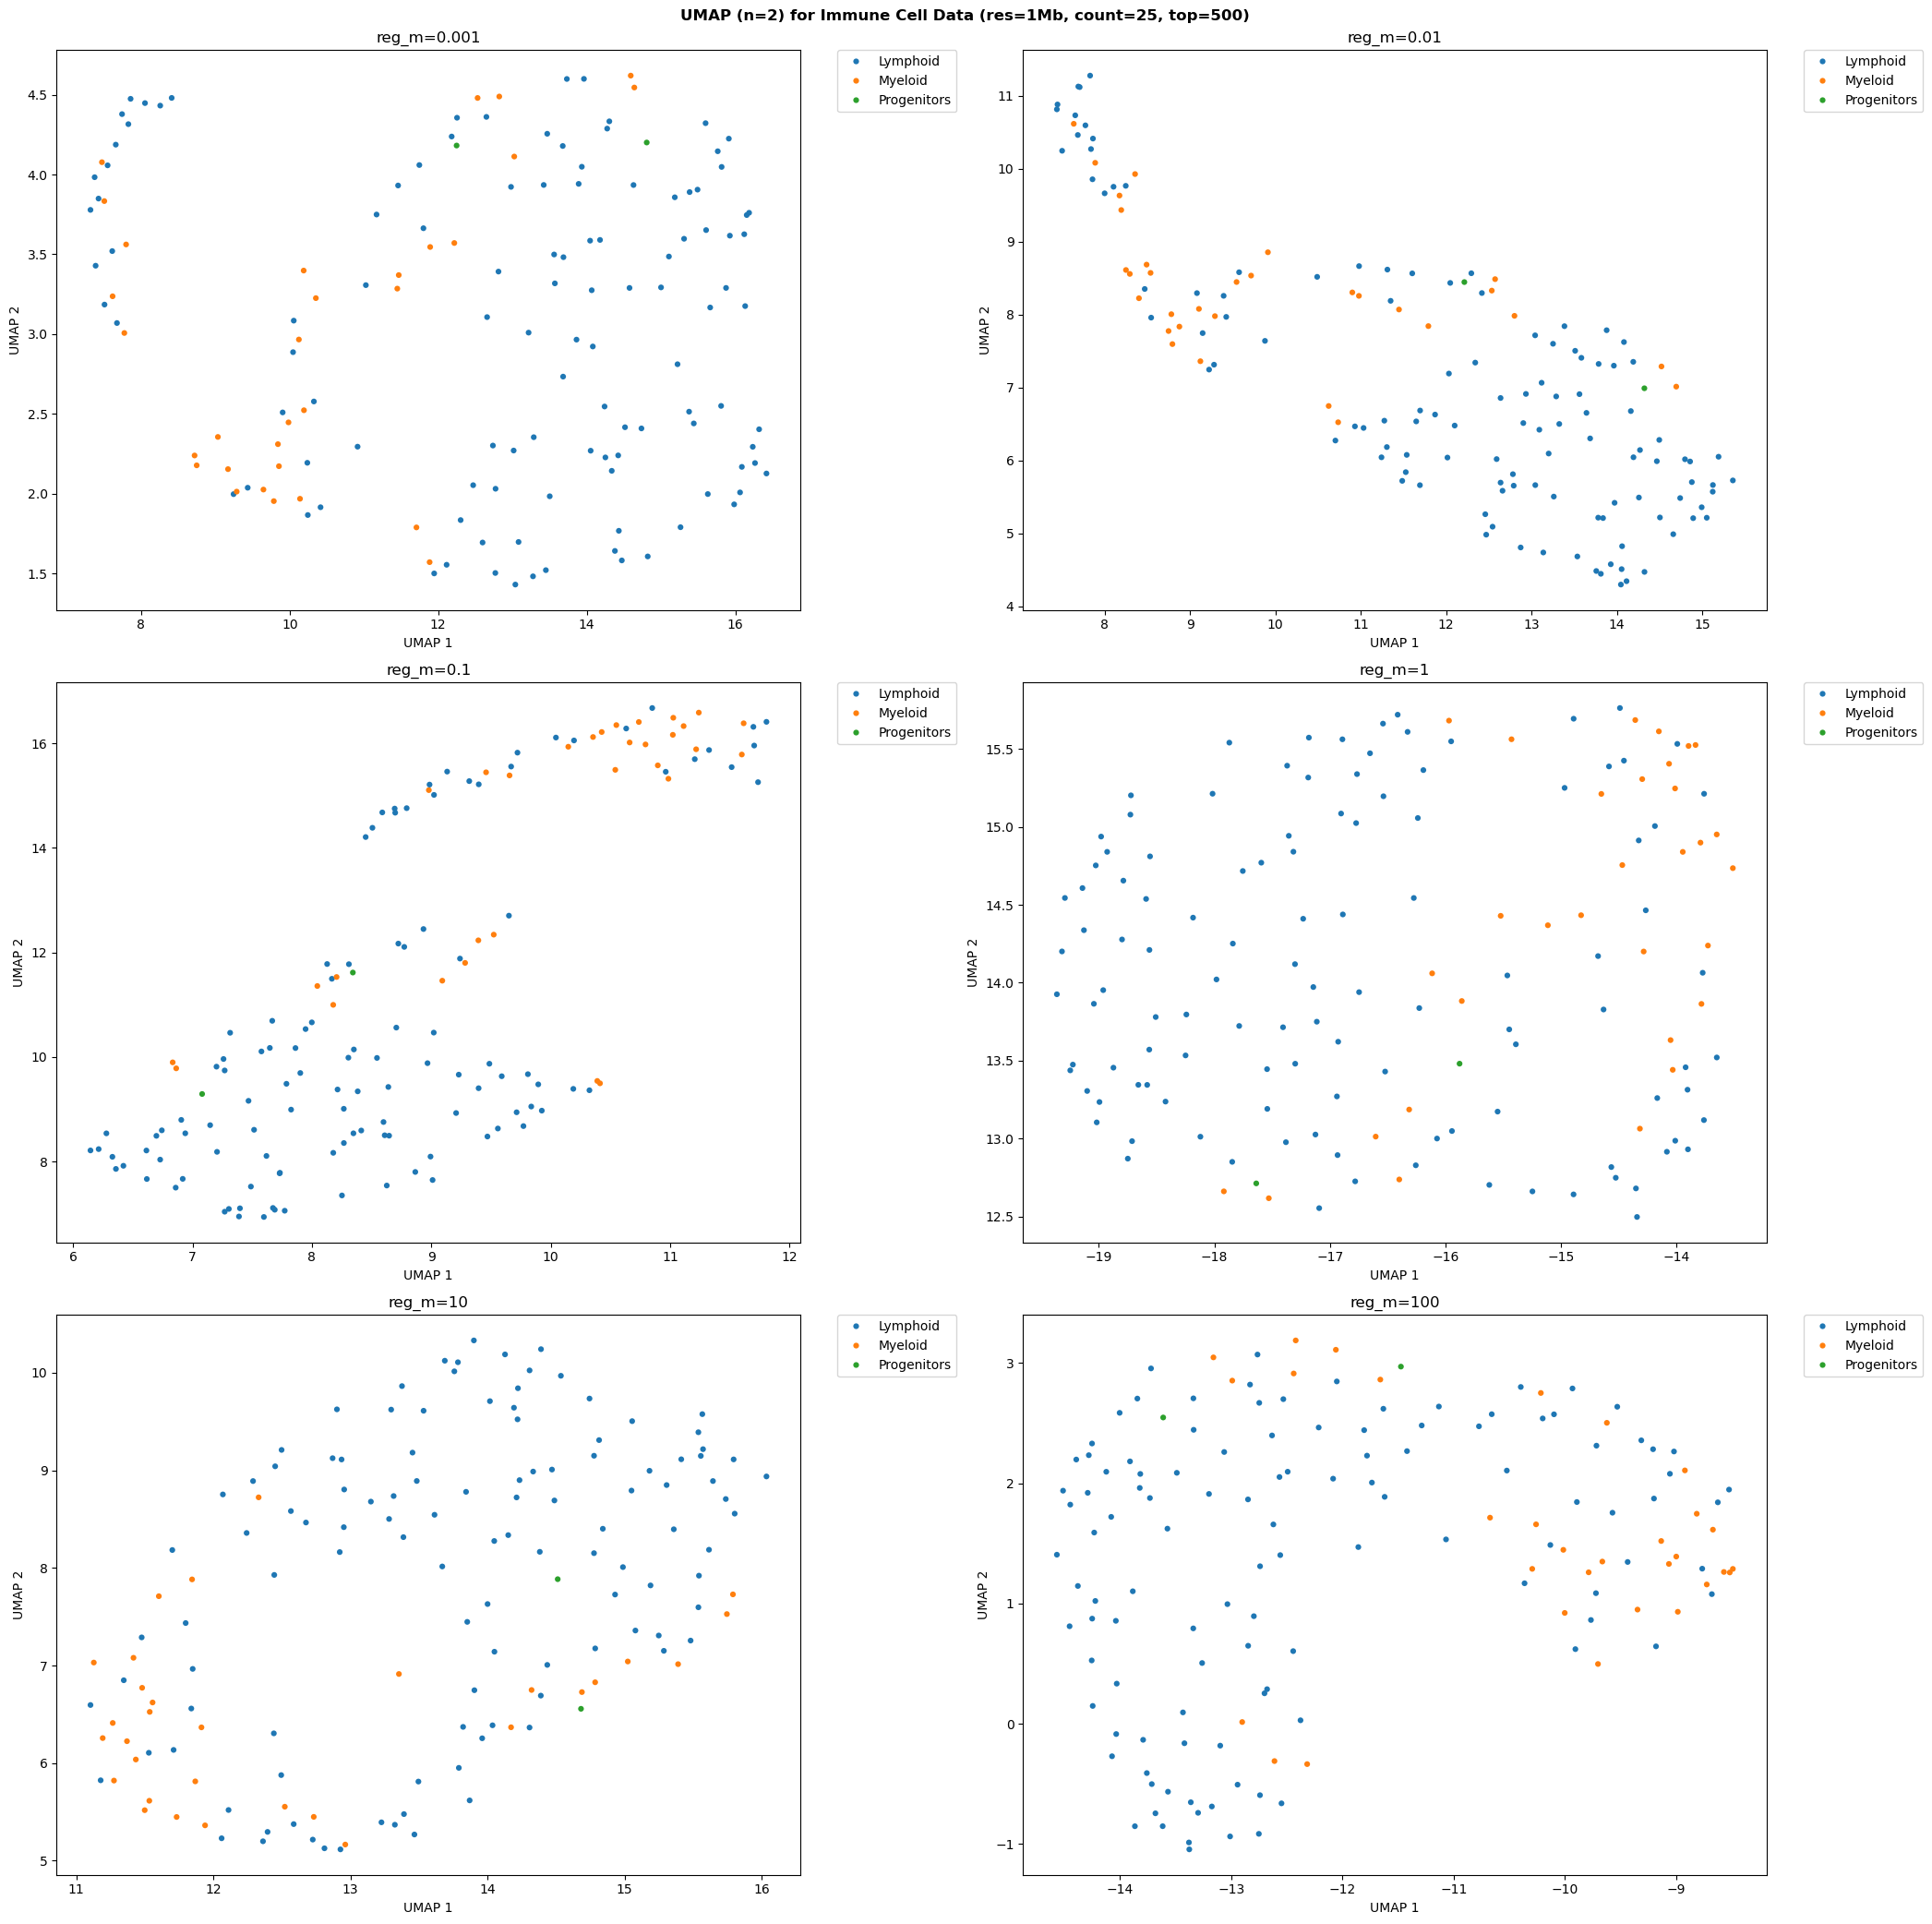

In [15]:
### Visualizing batched clustering, condensed ###
fig, ax = plt.subplots(3, 2, figsize=(21,21))
axes = ax.flatten()

    # Adding subpanels
for i, (reg_m, data) in enumerate(data_dict_condensed.items()):
    generate_clustering(data[0], data[1], f"reg_m={reg_m}", axes[i])

    # Adding titles
plt.suptitle("UMAP (n=2) for Immune Cell Data (res=1Mb, count=25, top=500)", fontweight="bold", y=0.99)
plt.tight_layout()

### Clustermap

## Reg

### Generating Data

In [12]:
### Setting Parameters ###
reg_list = [10e-5, 10e-4, 10e-3, 10e-2, 10e-1]

In [14]:
### Generating Data ###
times_list_reg = []
for reg in reg_list:
    print(f"Starting OT for reg={reg}")
    _, time = generate_ot_data(0.1, reg=reg)
    times_list_reg.append(time)

Starting OT for reg=0.0001


/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/HiCOT Experimenting/Single Cell/UOT/Immune Cells/../../../../../Scripts/hicdatautils/hicgeneral.py:136: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
  0%|          | 0/10731 [00:00<?, ?it/s]/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/ot/unbalanced/_sinkhorn.py:759: RuntimeWarning: overflow encountered in divide
  v = (b / Ktu) ** fi_2
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/ot/unbalanced/_sinkhorn.py:770: UserWarning: Numerical errors at iteration 25
  warnings.warn("Numerical errors at iteration %s" % i)
  0%|          | 16/10731 [00:01<20:40,  8.64it/s]/opt/an

Starting OT for reg=0.001


/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/HiCOT Experimenting/Single Cell/UOT/Immune Cells/../../../../../Scripts/hicdatautils/hicgeneral.py:136: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
  0%|          | 0/10731 [00:00<?, ?it/s]/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/ot/unbalanced/_sinkhorn.py:770: UserWarning: Numerical errors at iteration 35
  warnings.warn("Numerical errors at iteration %s" % i)
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/ot/unbalanced/_sinkhorn.py:770: UserWarning: Numerical errors at iteration 37
  warnings.warn("Numerical errors at iteration %s" % i)
/opt/anaconda3/envs/hicote

Starting OT for reg=0.01


/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/HiCOT Experimenting/Single Cell/UOT/Immune Cells/../../../../../Scripts/hicdatautils/hicgeneral.py:136: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
100%|██████████| 10731/10731 [00:52<00:00, 202.67it/s]


Starting OT for reg=0.1


/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/HiCOT Experimenting/Single Cell/UOT/Immune Cells/../../../../../Scripts/hicdatautils/hicgeneral.py:136: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
100%|██████████| 10731/10731 [00:16<00:00, 665.86it/s]


Starting OT for reg=1.0


/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/HiCOT Experimenting/Single Cell/UOT/Immune Cells/../../../../../Scripts/hicdatautils/hicgeneral.py:136: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
100%|██████████| 10731/10731 [00:14<00:00, 754.77it/s]


In [15]:
### Saving times ###
times_dict_reg = {
    "reg_m" : reg_list,
    "time" : times_list_reg
}

times_df_reg = pd.DataFrame.from_dict(times_dict_reg)
times_df_reg.to_csv(f'{save_dir}/uot_immmune_devianceguided_reg_times.csv')

### Loading Data

In [13]:
### Loading data into dict per reg ###
data_dict_reg_original = {}
data_dict_reg_condensed = {}
data_dict_reg_half = {}

for reg in reg_list:
    data_np_reg_original = load_ot_data_numpy(0.1, reg=reg, condense="not")
    data_np_reg_condensed = load_ot_data_numpy(0.1, reg=reg, condense="full")
    data_np_reg_half = load_ot_data_numpy(0.1, reg=reg, condense="half")

    data_dict_reg_original[reg] = data_np_reg_original
    data_dict_reg_condensed[reg]  = data_np_reg_condensed
    data_dict_reg_half[reg]  = data_np_reg_half

### UMAP

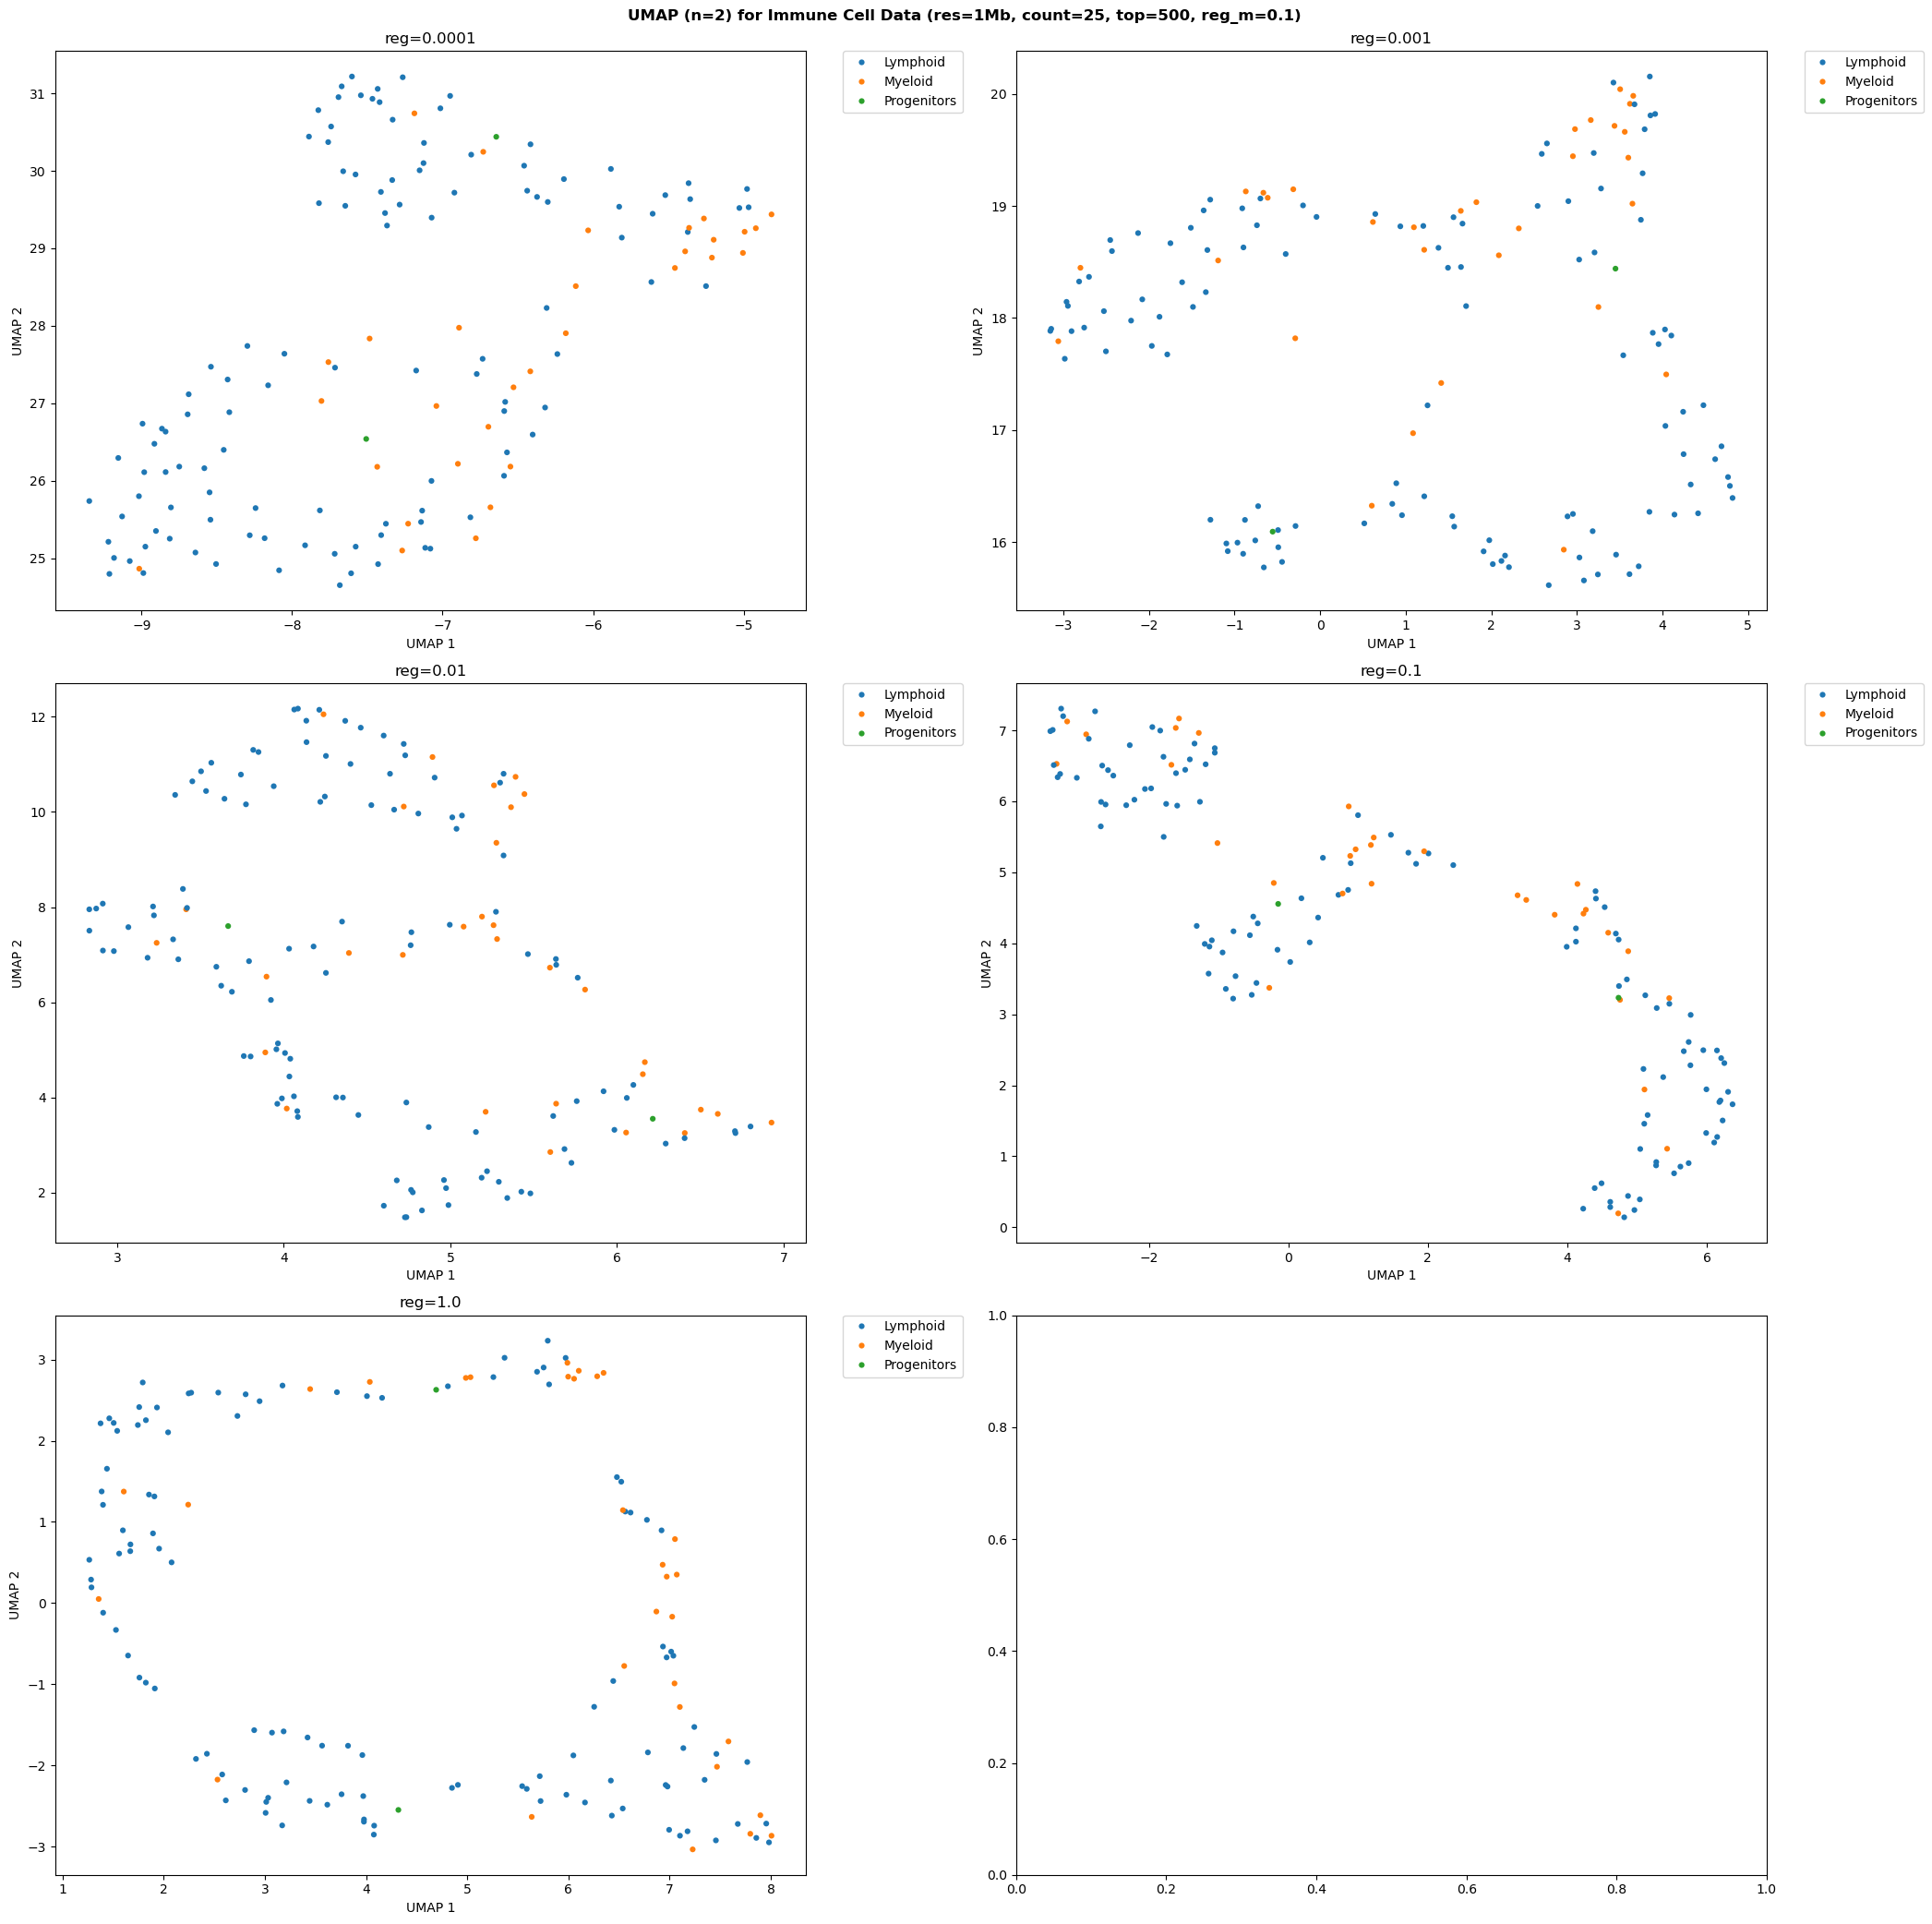

In [14]:
### Visualizing batched clustering, condensed ###
fig, ax = plt.subplots(3, 2, figsize=(21,21))
axes = ax.flatten()

    # Adding subpanels
for i, (reg, data) in enumerate(data_dict_reg_condensed.items()):
    generate_clustering(data[0], data[1], f"reg={reg}", axes[i])

    # Adding titles
plt.suptitle("UMAP (n=2) for Immune Cell Data (res=1Mb, count=25, top=500, reg_m=0.1)", fontweight="bold", y=0.99)
plt.tight_layout()